In [1]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm
import pandas as pd
import matplotlib.pyplot as plt
from estimation_forecast_functions import DataCleaner, BMSM_Forecaster_MLE, GARCH_Forecaster, FIGARCH_Forecaster
from numpy.linalg import solve, cholesky
from scipy.linalg import toeplitz, solve_triangular
from scipy.stats import chi2 
from scipy.special import polygamma
from autograd import grad
import autograd.numpy as anp

In [57]:
class NEW_LMSM_Estimator_GMM:

    def __init__(self, 
                 train_returns: np.ndarray, 
                 initial_params: np.ndarray,
                 lags: list[int] = [1, 5, 10, 20],
                 kbar: int = 10, 
                 b: float = 2.0, 
                 gamma_kbar: float = 0.5, 
                 max_iter: int = 100, 
                 param_tol: float = 1e-5,
                 W_tol: float = 1e-5
                 ) -> None:

        '''
        Parameters:
        train_returns: np.ndarray - array of log returns
        initial_params: np.ndarray - initial parameters for the LMSM, typically [lambda_hat, sigma_bar]
        lags: list[int] - list of lags for the moments
        kbar: int - number of lags in the LMSM
        b: float - parameter for the LMSM
        gamma_kbar: float - parameter for the LMSM
        max_iter: int - maximum number of iterations for the GMM estimation
        param_tol: float - tolerance for convergence of parameters
        W_tol: float - tolerance for convergence of the weighting matrix
        '''
        
        self.train_returns = train_returns
        self.initial_params = initial_params
        self.lags = lags
        self.kbar = kbar
        self.b = b
        self.gamma_kbar = gamma_kbar
        self.max_iter = max_iter
        self.param_tol = param_tol
        self.W_tol = W_tol


        self.gammas = 1 - (1 - self.gamma_kbar) ** (b ** (np.arange(1, kbar + 1) - kbar))

        first_order = -0.6351814227307391             
        second_order =  1.6371559899184157       
        third_order = -4.710737992756197        
        fourth_order = 19.148024309488146 
        self.log_abs_normal_moments = np.array([first_order, second_order, third_order, fourth_order])

        '''
        All of which are computed using the below but we hardcode to save time.
        first_order = 1/2 * (polygamma(0, 1/2) + np.log(2))
        second_order = 1/4 * (polygamma(1, 1/2) + (polygamma(0, 1/2) + np.log(2))**2)
        third_order = 1/8 * (polygamma(2, 1/2) + 3 * polygamma(1, 1/2) * (polygamma(0, 1/2) + np.log(2)) + (polygamma(0, 1/2) + np.log(2))**3)
        fourth_order = 1/16 * (polygamma(3, 1/2) + 4* polygamma(2, 1/2) * (polygamma(0, 1/2) + np.log(2)) + 3 * polygamma(1, 1/2)**2 + 6 * (polygamma(1, 1/2) * (polygamma(0, 1/2) + np.log(2)) **2) + (polygamma(0, 1/2) + np.log(2))**4)
        '''

    def get_theoretical_moments(self, lambda_hat, sigma_hat):
        '''
        Returns theoretical moments in order of moment q=1 and q=2 for each Tlag and finally the variance. We use formulas outlined
        in Lux (2008) only for this (non-RV version of the LMSM). 
        '''

        s2 = 2 * lambda_hat
        theoretical_moments = []

        for Tlag in self.lags:

            interior_sum1 = (1 - (1 - self.gammas) ** Tlag) # (1 - (1 - gamma_i) ** Tlag)
            eta_tpT_T_eta_t_T = - np.sum(interior_sum1 ** 2) * s2  # E[eta_t+T_T, eta_t, T]
            eta_tpT_T_2 = np.sum(interior_sum1) * 2 * s2  # E[eta_t+T, T ** 2]

            k1 = np.sum(interior_sum1 ** 2) * 6 * s2**2 # kappa 1

            # using sum_i,j(i !=j) ai aj = (sum_i ai)^2 - sum_i ai^2
            k2 = (np.sum(interior_sum1) ** 2 - np.sum(interior_sum1 ** 2)) * 4 * s2 ** 2 # kappa 2
            k3 = (np.sum(interior_sum1 ** 2) ** 2 - np.sum(interior_sum1 ** 4)) * 2 * s2 ** 2 # kappa 3
            eta_tpT_T_2_eta_t_T_2 = k1 + k2 + k3  # E[eta_t+T,T **2, eta_t,T ** 2]

            # now in xi space
            xi_tpT_T_xi_t_T = 0.25 * eta_tpT_T_eta_t_T + self.log_abs_normal_moments[0] ** 2 - self.log_abs_normal_moments[1]
            theoretical_moments.append(xi_tpT_T_xi_t_T)

            xi_tpT_T_2_xi_t_T_2 = 0.25 ** 2 * eta_tpT_T_2_eta_t_T_2 - (eta_tpT_T_2 - eta_tpT_T_eta_t_T) \
                                    * (self.log_abs_normal_moments[0] ** 2 - self.log_abs_normal_moments[1]) \
                                    + 3 * self.log_abs_normal_moments[1] ** 2 - 4 * self.log_abs_normal_moments[0] \
                                    * self.log_abs_normal_moments[2] + self.log_abs_normal_moments[3]
            
            theoretical_moments.append(xi_tpT_T_2_xi_t_T_2)

        # append the theoretical variance
        theoretical_moments.append(sigma_hat ** 2)

        theoretical_moments = np.array(theoretical_moments)
        return theoretical_moments
    
    def compute_moment_differences(self, lambda_hat, sigma_hat):
        '''
        Computes the moment differences for the LMSM model - f(phi) function returning the full shape per observation matrix
        (for the weighting matrix) and the expectation (vector version for the objective function).
        '''

        # x_t is our observations as in Lux (2008)
        eps = 1e-12
        log_abs_x_t = np.log(np.abs(self.train_returns) + eps)
        N = len(log_abs_x_t)
        moment_diff_matrix = []
        theoretical_moments = self.get_theoretical_moments(lambda_hat, sigma_hat)

        max_lag = max(self.lags)
        valid_range = range(max_lag, N - max_lag)

        for t in valid_range:
            
            g_t = []

            for idx, Tlag in enumerate(self.lags):

                xi_t_T = log_abs_x_t[t] - log_abs_x_t[t - Tlag]
                xi_tpT_T = log_abs_x_t[t + Tlag] - log_abs_x_t[t]

                moment_1_diff = xi_t_T * xi_tpT_T - theoretical_moments[2 * idx]
                g_t.append(moment_1_diff)

                moment_2_diff = (xi_t_T ** 2) * (xi_tpT_T ** 2) - theoretical_moments[2 * idx + 1]
                g_t.append(moment_2_diff)

            # variance term
            moment_var_diff = (self.train_returns[t] ** 2) - theoretical_moments[-1]
            g_t.append(moment_var_diff)

            moment_diff_matrix.append(g_t)

        moment_diff_matrix = np.array(moment_diff_matrix)
        moment_diff_vector = np.mean(moment_diff_matrix, axis=0)  # average over all T

        return moment_diff_matrix, moment_diff_vector
    
    def gmm_objective_function(self, params, W):

        log_lambda_hat = params[0]
        log_sigma_hat = params[1]

        lambda_hat = np.exp(log_lambda_hat)  # ensure lambda is positive
        sigma_hat = np.exp(log_sigma_hat)  # ensure sigma is positive

        _, moment_diff_vector = self.compute_moment_differences(lambda_hat, sigma_hat)

        obj = moment_diff_vector.T @ W @ moment_diff_vector

        return obj
    
    def update_weighting_matrix(self, params):
        '''
        Update by numerically computing covariance matrix of moment diffferences and invert it.
        Use Cholesky decomposition for numerical stability.
        '''

        log_lamb, log_sigma = params

        lamb = np.exp(log_lamb)  # ensure lambda is positive
        sigma = np.exp(log_sigma)  # ensure sigma is positive

        moment_diff_matrix, moment_diff_vector = self.compute_moment_differences(lamb, sigma)
        Cov = moment_diff_matrix.T @ moment_diff_matrix / moment_diff_matrix.shape[0]
        Cov += np.eye(Cov.shape[0]) * 1e-6  # add small value to diagonal for numerical stability


        # cholesky
        L = cholesky(Cov)  
        I = np.eye(Cov.shape[0])
        L_inv = solve_triangular(L, I, lower=True)
        W_new = L_inv.T @ L_inv

        return W_new



    def estimate_lmsm(self):

        bounds = [(None, 1), (None, 1)]
        
        W_curr = np.eye(len(self.lags) * 2 + 1)  # initial weighting matrix
        curr_params_transformed = np.array([np.log(self.initial_params[0]), np.log(self.initial_params[1])])

        for i in range(self.max_iter):

            result = minimize(self.gmm_objective_function, 
                              curr_params_transformed, 
                              args=(W_curr,), 
                              method='L-BFGS-B',
                              bounds=bounds,
                              options={'ftol': 1e-6, 'gtol': 1e-6, 'maxiter': 1000, 'maxls': 50})

            if result.success:
                new_params_transformed = result.x
                new_W = self.update_weighting_matrix(new_params_transformed)
            else:
                print("Optimisation failed.")
                print(result.message)
                break

            # test convergence using abs diff of infinty norm
            param_err = np.linalg.norm(new_params_transformed - curr_params_transformed, ord=np.inf)
            W_err = np.linalg.norm(new_W - W_curr, ord='fro')
            print(f"Iteration {i+1}: param_err={param_err:.6f}, W_err={W_err:.6f}")

            if param_err < self.param_tol and W_err < self.W_tol:
                print(f"Converged after {i+1} iterations with param_err={param_err:.6f}, W_err={W_err:.6f}")
                break

            curr_params_transformed = new_params_transformed
            W_curr = new_W

        else:
            print(f"Did not converge after {self.max_iter} iterations with param_err={param_err:.6f}, W_err={W_err:.6f}")

        self.final_lambda_hat = np.exp(curr_params_transformed[0])
        self.final_sigma_bar = np.exp(curr_params_transformed[1])
        print(f"Final estimates: lambda_hat = {self.final_lambda_hat}, sigma_bar = {self.final_sigma_bar:.6f}")

        return self.final_lambda_hat, self.final_sigma_bar, result, W_curr
        

In [36]:
# pip install pandas_datareader
import pandas_datareader.data as web
import datetime as dt

start = dt.datetime(1979, 1, 1)
end   = dt.datetime(1996, 12, 31)

df = web.DataReader('DEXJPUS', 'fred', start, end)


X = df.copy()
X['r'] = np.log(X['DEXJPUS']).diff()            # this or linear r makes no diff neither does percentage on actual values
#X['r'] = X['DEXJPUS'] / X['DEXJPUS'].shift(1) - 1
X = X[1:]
Y = X['r'].values
Y = Y[~np.isnan(Y)]  
initial_params = np.array([0.4, np.std(Y)]) 

In [24]:
train_returns = np.load("/Users/alexvillamartin/Documents/MSc Diss/Code/all_paths_Lmsm_lamb_0.1.npz")['r']

In [59]:
test = NEW_LMSM_Estimator_GMM(train_returns=Y*100, 
                             initial_params=np.array([0.1, np.std(Y)*100]),
                             lags=[1, 5, 10, 20], 
                             kbar=15, 
                             b=2.0, 
                             gamma_kbar=0.5, 
                             max_iter=10, 
                             param_tol=1e-4,
                             W_tol=1e-3)

lambd, sigma_bar, res, W = test.estimate_lmsm()

Iteration 1: param_err=3.302585, W_err=2.816830
Iteration 2: param_err=5.814900, W_err=0.016118
Iteration 3: param_err=0.002887, W_err=0.000026
Iteration 4: param_err=0.000132, W_err=0.000000
Iteration 5: param_err=0.000132, W_err=0.000000
Iteration 6: param_err=0.000132, W_err=0.000000
Iteration 7: param_err=0.000132, W_err=0.000000
Iteration 8: param_err=0.000132, W_err=0.000000
Iteration 9: param_err=0.000132, W_err=0.000000
Iteration 10: param_err=0.000132, W_err=0.000000
Did not converge after 10 iterations with param_err=0.000132, W_err=0.000000
Final estimates: lambda_hat = 0.00809642091249998, sigma_bar = 0.660602


In [38]:
ma, ve = test.compute_moment_differences(lambd, sigma_bar)
ve

array([-1.07557461e+01,  7.68424971e+03, -1.14255751e+01,  8.30394762e+03,
       -1.19372712e+01,  8.50511819e+03, -1.14887013e+01,  8.20347949e+03,
       -1.27914016e-02])

In [45]:
corr = np.corrcoef(ma.T)

In [46]:
corr

array([[ 1.        , -0.99428253,  0.9218602 , -0.91668168,  0.91699594,
        -0.91466595,  0.91286211, -0.91423501,  0.04889629],
       [-0.99428253,  1.        , -0.92070003,  0.91711039, -0.91360722,
         0.91198381, -0.91213212,  0.91474237, -0.05723527],
       [ 0.9218602 , -0.92070003,  1.        , -0.99542602,  0.94385783,
        -0.94562525,  0.93088026, -0.92937234,  0.051616  ],
       [-0.91668168,  0.91711039, -0.99542602,  1.        , -0.94059983,
         0.94330158, -0.92648137,  0.92564917, -0.05826339],
       [ 0.91699594, -0.91360722,  0.94385783, -0.94059983,  1.        ,
        -0.99528905,  0.94548765, -0.94506098,  0.04924202],
       [-0.91466595,  0.91198381, -0.94562525,  0.94330158, -0.99528905,
         1.        , -0.94668659,  0.9465661 , -0.05892926],
       [ 0.91286211, -0.91213212,  0.93088026, -0.92648137,  0.94548765,
        -0.94668659,  1.        , -0.99528473,  0.0485158 ],
       [-0.91423501,  0.91474237, -0.92937234,  0.92564917, -0

Seems serially correlated.

In [265]:
train_returns = np.load("/Users/alexvillamartin/Documents/MSc Diss/Code/all_paths_Lmsm_lamb_0.1.npz")['r']
initial_params = np.array([0.1, 0.007*100])  

test = NEW_LMSM_Estimator_GMM(train_returns=(train_returns[:, 1])*100, 
                             initial_params=initial_params,
                             lags=[1, 5, 10, 20], 
                             kbar=10, 
                             b=2.0, 
                             gamma_kbar=0.5, 
                             max_iter=100, 
                             param_tol=1e-6,
                             W_tol=1e-6)

lambd, sigma_bar, res = test.estimate_lmsm()

Iteration 1: param_err=0.335847, W_err=3.626755
Iteration 2: param_err=0.038489, W_err=0.000000
Iteration 3: param_err=0.000000, W_err=0.000000
Converged after 3 iterations with param_err=0.000000, W_err=0.000000
Final estimates: lambda_hat = 0.18882423930435846, sigma_bar = 0.364764
Iteration 2: param_err=0.038489, W_err=0.000000
Iteration 3: param_err=0.000000, W_err=0.000000
Converged after 3 iterations with param_err=0.000000, W_err=0.000000
Final estimates: lambda_hat = 0.18882423930435846, sigma_bar = 0.364764


In [223]:
lambs = []
sigmas = []
for i in range(400):
    initial_params = np.array([0.1, np.std(train_returns[:, i])])  
    test = NEW_LMSM_Estimator_GMM(train_returns=train_returns[:, i],
                                    initial_params=initial_params,
                                    lags=[1, 5, 10, 20], 
                                    kbar=10, 
                                    b=2.0, 
                                    gamma_kbar=0.5, 
                                    max_iter=50, 
                                    param_tol=1e-6,
                                    W_tol=1e-6)
    
    lamb_hat, sigma_hat, res = test.estimate_lmsm()
    lambs.append(lamb_hat)
    sigmas.append(sigma_hat)

Iteration 1: param_err=0.046361, W_err=1071182.342067
Iteration 2: param_err=0.011466, W_err=0.000000
Iteration 3: param_err=0.000000, W_err=0.000000
Converged after 3 iterations with param_err=0.000000, W_err=0.000000
Final estimates: lambda_hat = 0.1578275417935574, sigma_bar = 0.010508
Iteration 1: param_err=0.127313, W_err=448234565.115969
Iteration 2: param_err=0.038489, W_err=0.000000
Iteration 3: param_err=0.000000, W_err=0.000000
Converged after 3 iterations with param_err=0.000000, W_err=0.000000
Final estimates: lambda_hat = 0.1888238322236155, sigma_bar = 0.003648
Iteration 1: param_err=0.016669, W_err=1298772237.665717
Iteration 2: param_err=0.026194, W_err=0.000000
Iteration 3: param_err=0.000000, W_err=0.000000
Converged after 3 iterations with param_err=0.000000, W_err=0.000000
Final estimates: lambda_hat = 0.14286275478031193, sigma_bar = 0.003071
Iteration 1: param_err=0.040116, W_err=8826705.508931
Iteration 2: param_err=0.061915, W_err=0.000000
Iteration 3: param_err

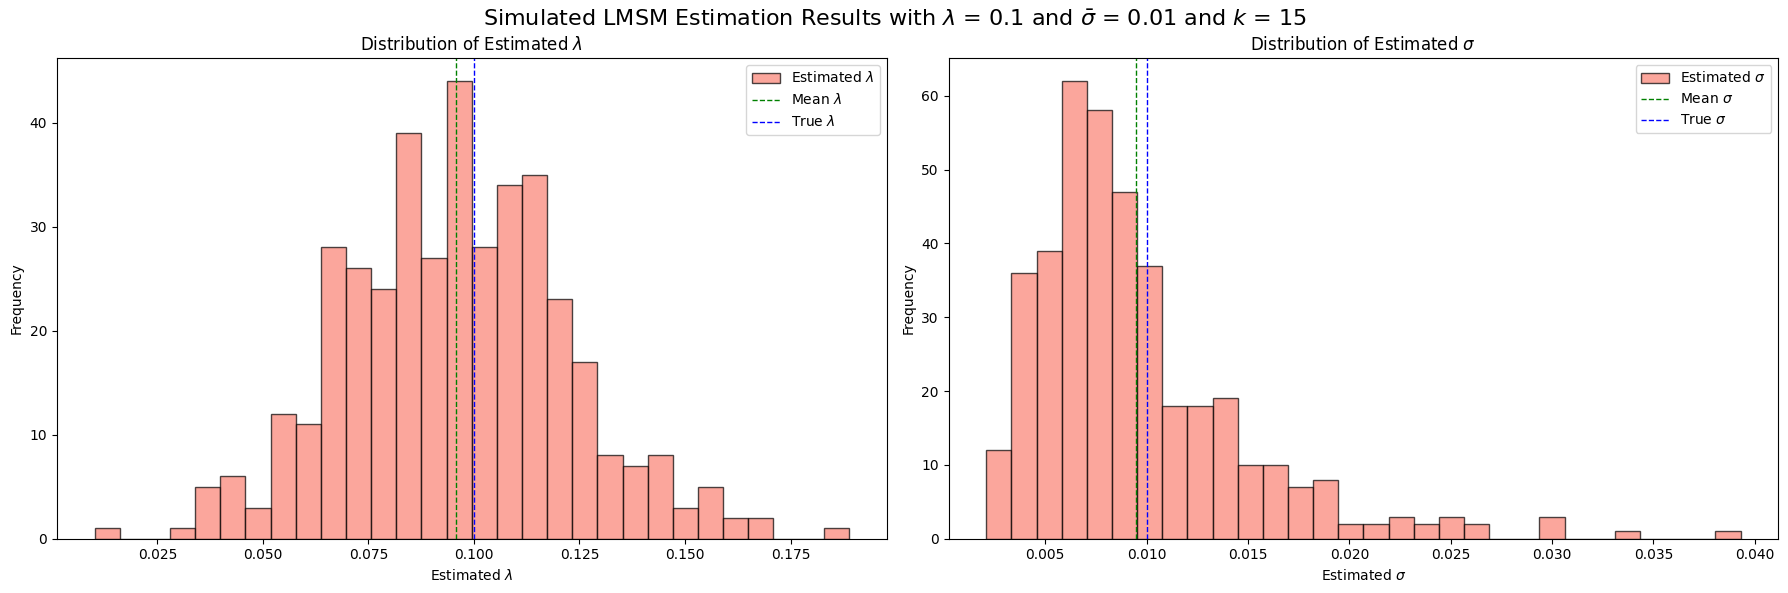

In [233]:
mean_lambda = np.mean(lambs)
mean_sigma = np.mean(sigmas)

true_lambda_ = 0.1
true_sigma_bar = 0.01

plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.hist(lambs, bins=30, alpha=0.7, label=r'Estimated $\lambda$', color = 'salmon', edgecolor='black')
plt.axvline(mean_lambda, color='green', linestyle='dashed', linewidth=1, label=r'Mean $\lambda$')
plt.axvline(true_lambda_, color='blue', linestyle='dashed', linewidth=1, label=r'True $\lambda$')
plt.xlabel(r'Estimated $\lambda$')
plt.ylabel('Frequency')
plt.title(r'Distribution of Estimated $\lambda$')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(sigmas, bins=30, alpha=0.7, label=r'Estimated $\sigma$', color = 'salmon', edgecolor='black')
plt.axvline(mean_sigma, color='green', linestyle='dashed', linewidth=1, label=r'Mean $\sigma$')
plt.axvline(true_sigma_bar, color='blue', linestyle='dashed', linewidth=1, label=r'True $\sigma$')
plt.xlabel(r'Estimated $\sigma$')
plt.ylabel('Frequency')
plt.title(r'Distribution of Estimated $\sigma$')
plt.legend()

plt.tight_layout()
plt.suptitle(fr'Simulated LMSM Estimation Results with $\lambda$ = {true_lambda_} and $\bar{{\sigma}}$ = {true_sigma_bar} and $k$ = 15', fontsize=16)
plt.subplots_adjust(top=0.90) 
plt.savefig('/Users/alexvillamartin/Documents/MSc Diss/plots_new/lmsm_estimation_results_0_1_lambd_k_15.png')
plt.show()

In [234]:
mean_lambda, mean_sigma = np.mean(lambs), np.mean(sigmas)
print(f"Mean estimated lambda: {mean_lambda}, Mean estimated sigma: {mean_sigma}")
print(f"True lambda: {true_lambda_}, True sigma: {true_sigma_bar}")

rmse_lamb = np.sqrt(np.mean((np.array(lambs) - true_lambda_)**2))
rmse_sigma = np.sqrt(np.mean((np.array(sigmas) - true_sigma_bar)**2))
print(f"RMSE for lambda: {rmse_lamb}, RMSE for sigma: {rmse_sigma}")

Mean estimated lambda: 0.09578342247745698, Mean estimated sigma: 0.009478585023686308
True lambda: 0.1, True sigma: 0.01
RMSE for lambda: 0.027011694070891292, RMSE for sigma: 0.005347475882322856


In [149]:
lambdas = []
sigmas = []

train_log_returns = np.load("/Users/alexvillamartin/Documents/MSc Diss/Code/all_paths_Lmsm.npz")['r']
npaths = 400
true_lambda_ = 0.05
true_sigma_bar = 1.0 # when we do percent terms this goes from 0.01 > 1

for i in range(npaths):
    initial_params = [0.1, np.std(train_log_returns[:, i])*100]
    LMSM_estimator = LMSM_Estimator_GMM(train_log_returns[:, i],
                                        initial_params=initial_params,
                                        kbar=10,
                                        b=2.0,
                                        gamma_kbar=0.5,
                                        moment_lags=[1, 5, 10, 20],
                                        scale=100,
                                        percent_terms=True,
                                        max_iter = 50, 
                                        param_tol=1e-8, 
                                        W_tol=1e-4)
    
    final_lambda_hat, final_sigma_bar, res = LMSM_estimator.estimate_rv_lmsm()
    lambdas.append(final_lambda_hat)
    sigmas.append(final_sigma_bar)

Converged after 2 iterations with param_err=0.000000, W_err=0.000000
lambda_hat = 0.0345530251754115, sigma_bar = 0.919347
Converged after 2 iterations with param_err=0.000000, W_err=0.000000
lambda_hat = 0.05804157984764702, sigma_bar = 0.764599
Converged after 3 iterations with param_err=0.000000, W_err=0.000000
lambda_hat = 0.008300449320997048, sigma_bar = 0.924146
Converged after 5 iterations with param_err=0.000000, W_err=0.000000
lambda_hat = 0.00253677300454022, sigma_bar = 1.017642
Converged after 6 iterations with param_err=0.000000, W_err=0.000000
lambda_hat = 0.05612306573168627, sigma_bar = 1.179309
Converged after 6 iterations with param_err=0.000000, W_err=0.000000
lambda_hat = 0.009975667147651525, sigma_bar = 0.862895
Converged after 2 iterations with param_err=0.000000, W_err=0.000000
lambda_hat = 0.11187704947115333, sigma_bar = 0.974246
Converged after 5 iterations with param_err=0.000000, W_err=0.000000
lambda_hat = 0.035009241659933396, sigma_bar = 0.876911
Conver

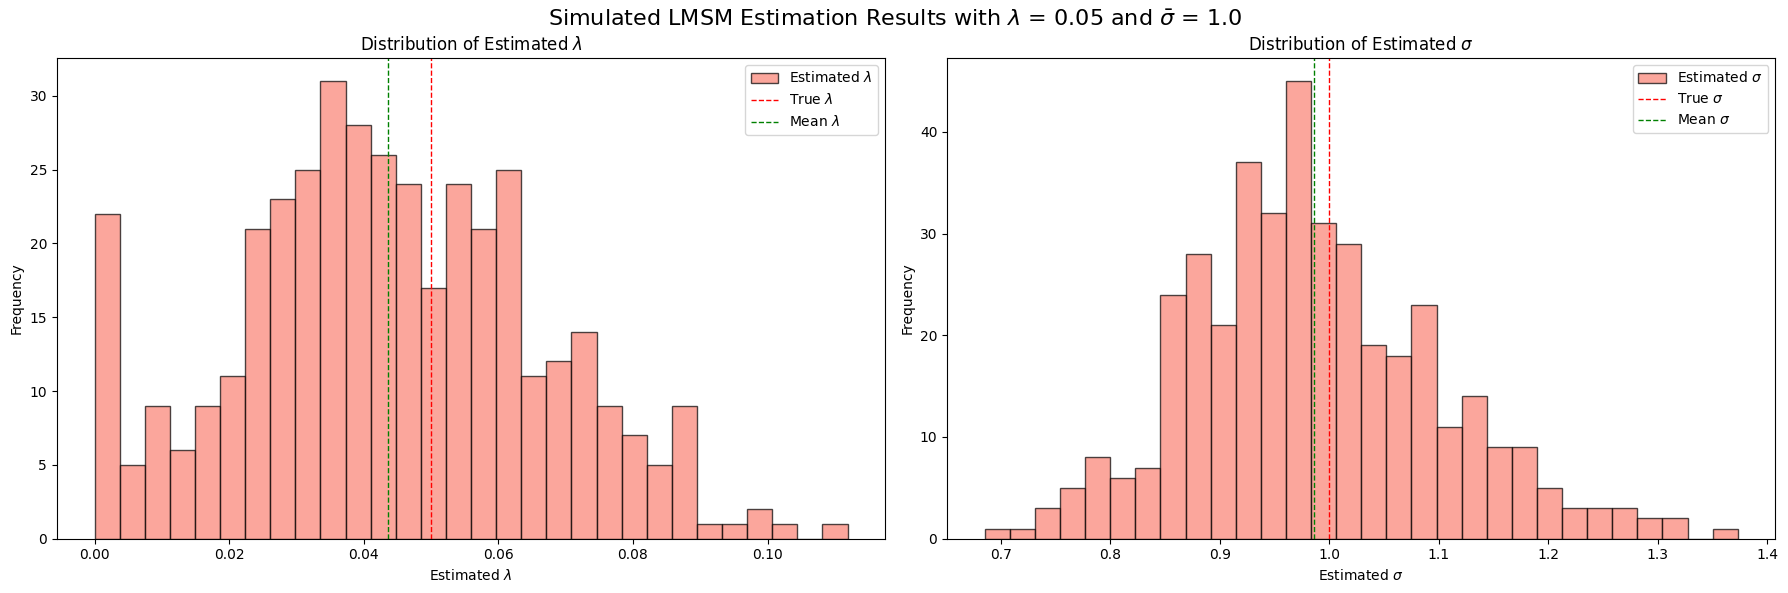

In [150]:
mean_lambda = np.mean(lambdas)
mean_sigma = np.mean(sigmas)

plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.hist(lambdas, bins=30, alpha=0.7, label=r'Estimated $\lambda$', color = 'salmon', edgecolor='black')
plt.axvline(true_lambda_, color='red', linestyle='dashed', linewidth=1, label=r'True $\lambda$')
plt.axvline(mean_lambda, color='green', linestyle='dashed', linewidth=1, label=r'Mean $\lambda$')
plt.xlabel(r'Estimated $\lambda$')
plt.ylabel('Frequency')
plt.title(r'Distribution of Estimated $\lambda$')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(sigmas, bins=30, alpha=0.7, label=r'Estimated $\sigma$', color = 'salmon', edgecolor='black')
plt.axvline(true_sigma_bar, color='red', linestyle='dashed', linewidth=1, label=r'True $\sigma$')
plt.axvline(mean_sigma, color='green', linestyle='dashed', linewidth=1, label=r'Mean $\sigma$')
plt.xlabel(r'Estimated $\sigma$')
plt.ylabel('Frequency')
plt.title(r'Distribution of Estimated $\sigma$')
plt.legend()

plt.tight_layout()
plt.suptitle(fr'Simulated LMSM Estimation Results with $\lambda$ = {true_lambda_} and $\bar{{\sigma}}$ = {true_sigma_bar}', fontsize=16)
plt.subplots_adjust(top=0.90) 
plt.savefig('/Users/alexvillamartin/Documents/MSc Diss/plots_new/lmsm_estimation_results.png')
plt.show()

In [151]:
rmse = np.sqrt(np.mean((np.array(lambdas) - true_lambda_)**2))
print(f"RMSE of estimated lambda: {rmse:.6f}")

rmse_sigma = np.sqrt(np.mean((np.array(sigmas) - true_sigma_bar)**2))
print(f"RMSE of estimated sigma: {rmse_sigma:.6f}")

RMSE of estimated lambda: 0.023254
RMSE of estimated sigma: 0.114145


In [153]:
print(f"Mean of estimated lambda: {mean_lambda:.6f}")
print(f"Mean of estimated sigma: {mean_sigma:.6f}")

Mean of estimated lambda: 0.043640
Mean of estimated sigma: 0.985765


Seem to have a lot more lock in here with lambdas going to zero. Try removing lock ins to see effect on plots. 

In [164]:
lambda_0_removed = lambdas.copy()
for i in range(len(lambda_0_removed)):
    if lambda_0_removed[i] < 1e-4:
        lambda_0_removed[i] = np.nan
lambda_0_removed = np.array(lambda_0_removed)[~np.isnan(lambda_0_removed)]

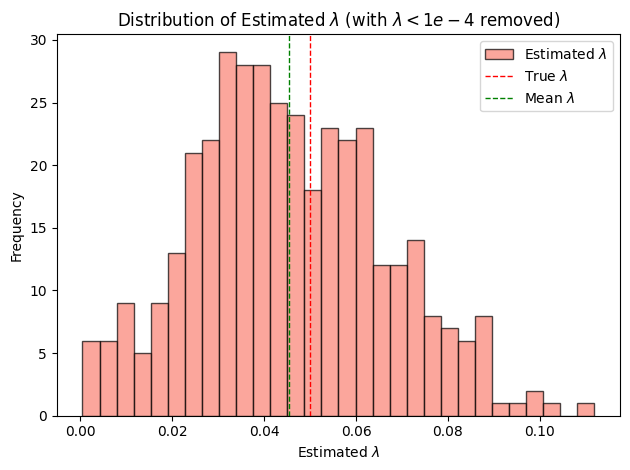

In [166]:
plt.hist(lambda_0_removed, bins=30, alpha=0.7, label=r'Estimated $\lambda$', color = 'salmon', edgecolor='black')
plt.axvline(true_lambda_, color='red', linestyle='dashed', linewidth=1, label=r'True $\lambda$')
plt.axvline(np.mean(lambda_0_removed), color='green', linestyle='dashed', linewidth=1, label=r'Mean $\lambda$')
plt.xlabel(r'Estimated $\lambda$')
plt.ylabel('Frequency')
plt.title(r'Distribution of Estimated $\lambda$ (with $\lambda < 1e-4$ removed)')
plt.legend()
plt.tight_layout()
plt.savefig('/Users/alexvillamartin/Documents/MSc Diss/plots_new/lmsm_estimation_results_no_lock_in.png')
plt.show()

In [169]:
np.mean(lambda_0_removed)

np.float64(0.04545826954566492)

# Forecasting RV using LMSM

In [25]:
# pip install pandas_datareader
import pandas_datareader.data as web
import datetime as dt

start = dt.datetime(1979, 1, 1)
end   = dt.datetime(1996, 12, 31)

df = web.DataReader('DEXJPUS', 'fred', start, end)


X = df.copy()
X['r'] = np.log(X['DEXJPUS']).diff()            # this or linear r makes no diff neither does percentage on actual values
#X['r'] = X['DEXJPUS'] / X['DEXJPUS'].shift(1) - 1
X = X[1:]
Y = X['r'].values
Y = Y[~np.isnan(Y)]  
initial_params = np.array([0.4, np.std(Y)]) 

In [26]:
test = NEW_LMSM_Estimator_GMM(train_returns=Y , 
                             initial_params=initial_params,
                             lags=[1, 5, 10, 20], 
                             kbar=10, 
                             b=2.0, 
                             gamma_kbar=0.5, 
                             max_iter=100, 
                             param_tol=1e-4,
                             W_tol=1e-6)

lambd, sigma_bar, res = test.estimate_lmsm()

Iteration 1: param_err=11.779041, W_err=991727.691098
Iteration 2: param_err=11.591118, W_err=0.000000
Iteration 3: param_err=0.000003, W_err=0.000000
Converged after 3 iterations with param_err=0.000003, W_err=0.000000
Final estimates: lambda_hat = 0.5879237635625, sigma_bar = 0.006503


In [56]:
martr, vec = test.compute_moment_differences(3, sigma_bar)

In [57]:
vec

array([-6.70740159e+00,  3.54429686e+03, -4.49978150e+00,  3.69513594e+03,
       -3.43114696e+00,  3.68884135e+03, -1.62619067e+00,  3.41573759e+03,
        2.36632355e-07])

In [13]:
theo = test.get_theoretical_moments(0.11, sigma_bar)

In [14]:
theo

array([-1.25407253e+00,  1.59459489e+01, -1.35073209e+00,  1.76405594e+01,
       -1.40562221e+00,  1.85686380e+01, -1.46061216e+00,  1.95293520e+01,
        4.37276891e-05])

# Forecasting RV using BMSM

In [18]:
# define params
m0 = 1.4
m1 = 2 - m0
b = 2
k_bar = 8
sigma_bar = 0.01
gamma_k_bar = 0.5
n = 2_500
S0 = 10
npaths = 400

def get_gammas(k_bar, gamma_k_bar, b):
    '''
    This function gets the gamma renewal probabilitie from the gamma k bar param.
    '''

    gammas = np.zeros(k_bar)
    gammas[-1] = gamma_k_bar
    for i in range(k_bar - 1, 0, -1):
        gammas[i-1] = 1 - (1 - gamma_k_bar) ** (b ** ((i - k_bar)))
                                                
    return gammas                 

def renew_multipliers(gammas, m0, M_t):
    '''
    This function does the renewal/keep previous calculation based on binomial dist.
    '''
    
    M_t_1 = np.zeros(len(gammas))

    for i in range(len(gammas)):
        curr_gam = gammas[i]

        if np.random.rand() <= curr_gam:
            new_draw = np.random.choice([m0, 2-m0], p = [0.5, 0.5])
            M_t_1[i] = new_draw
        else:
            M_t_1[i] = M_t[i]

    return M_t_1

def initial_multipliers(k_bar, m0):
    '''
    This function computes the initial multipliers to start of the simulation. 
    '''

    M_0 = np.zeros(k_bar)

    for i in range(k_bar):
        M_0[i] = np.random.choice([m0, 2-m0], p = [0.5, 0.5])

    return M_0

def simulate_msm(m0, n, b, k_bar, sigma_bar, gamma_k_bar, S0):

    r_t = np.zeros(n)
    logS = np.zeros(n)
    logS[0] = np.log(S0)
    sigma2_t = np.zeros(n)

    M_0 = initial_multipliers(k_bar, m0)
    gammas = get_gammas(k_bar, gamma_k_bar, b)
    
    sigma2_t[0] = sigma_bar ** 2 * np.prod(M_0)
    innovation_0 = norm.rvs()
    r_t[0] = np.sqrt(sigma2_t[0]) * innovation_0
    M_t = M_0

    for t in range(1, n):
    
        M_t = renew_multipliers(gammas, m0, M_t)
        sigma2_t[t] = sigma_bar ** 2 * np.prod(M_t)
        innovation_t = norm.rvs()
        r_t[t] = np.sqrt(sigma2_t[t]) * innovation_t
        logS[t] = logS[t-1] - 0.5 * sigma2_t[t] + r_t[t] # remove bias 

    S_t = np.exp(logS)

    return r_t, sigma2_t, S_t


r = np.zeros((n, npaths))
h = np.zeros((n, npaths))
S = np.zeros((n, npaths))

for i in range(npaths):
    r[:, i], h[:, i], S[:, i] = simulate_msm(m0, n, b, k_bar, sigma_bar, gamma_k_bar, S0)

In [21]:
m0s = []
sigma_bars = []


for i in range(npaths):

    if i % 50 == 0:
        print(f"Processing path {i+1}/{npaths}")

    bmsm_forecasts = BMSM_Forecaster_MLE(
        initial_params=initial_params,
        train_data=r[:, i].flatten(),
        test_data=test_log_returns.values.flatten(),
        test_realised_variance=test_realised_variance.values.flatten(),
        kbar=8,
        H=H, 
        scale=100, 
        b = 2.0, 
        gamma_kbar=0.5,
        percent_space=True)

    result, logL = bmsm_forecasts.estimate_msm_params() 

    m0s.append(result.x[0])
    sigma_bars.append(result.x[1])

Processing path 1/400
Estimated parameters: m0=1.400718e+00, sigma_bar=9.050448e-01
Final log-likelihood: -2.833811e+03
Estimated parameters: m0=1.399111e+00, sigma_bar=1.110023e+00
Final log-likelihood: -3.228469e+03
Estimated parameters: m0=1.429887e+00, sigma_bar=1.009204e+00
Final log-likelihood: -2.805232e+03
Estimated parameters: m0=1.405504e+00, sigma_bar=1.047769e+00
Final log-likelihood: -3.033552e+03
Estimated parameters: m0=1.424005e+00, sigma_bar=1.029459e+00
Final log-likelihood: -2.817285e+03
Estimated parameters: m0=1.377648e+00, sigma_bar=9.903720e-01
Final log-likelihood: -3.087718e+03
Estimated parameters: m0=1.397414e+00, sigma_bar=7.927975e-01
Final log-likelihood: -2.401966e+03
Estimated parameters: m0=1.403161e+00, sigma_bar=9.036837e-01
Final log-likelihood: -2.827081e+03
Estimated parameters: m0=1.348550e+00, sigma_bar=7.310902e-01
Final log-likelihood: -2.295492e+03
Estimated parameters: m0=1.376531e+00, sigma_bar=9.606518e-01
Final log-likelihood: -3.101031e+0

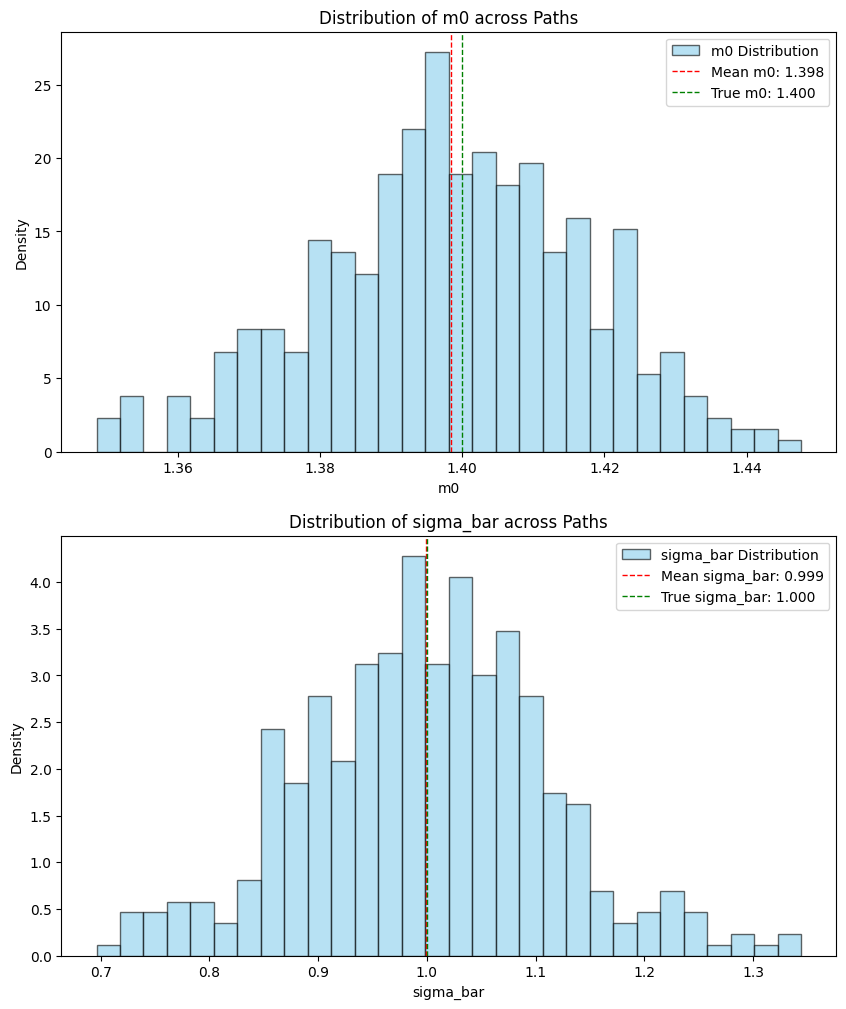

In [29]:
mean_m0 = np.mean(m0s)
mean_sigma_bar = np.mean(sigma_bars)
true_m0 = 1.4
true_sigma_bar = 1.0

plt.figure(figsize=(10, 12))

plt.subplot(2, 1, 1)
plt.hist(m0s, bins=30, density=True, alpha=0.6, color='skyblue', label='m0 Distribution', edgecolor='black')
plt.axvline(mean_m0, color='red', linestyle='dashed', linewidth=1, label=f'Mean m0: {mean_m0:.3f}')
plt.axvline(true_m0, color='green', linestyle='dashed', linewidth=1, label=f'True m0: {true_m0:.3f}')
plt.xlabel('m0')
plt.ylabel('Density')
plt.title('Distribution of m0 across Paths')
plt.legend()

plt.subplot(2, 1, 2)
plt.hist(sigma_bars, bins=30, density=True, alpha=0.6, color='skyblue', label='sigma_bar Distribution', edgecolor='black')
plt.axvline(mean_sigma_bar, color='red', linestyle='dashed', linewidth=1, label=f'Mean sigma_bar: {mean_sigma_bar:.3f}')
plt.axvline(true_sigma_bar, color='green', linestyle='dashed', linewidth=1, label=f'True sigma_bar: {true_sigma_bar:.3f}')
plt.xlabel('sigma_bar')
plt.ylabel('Density')
plt.title('Distribution of sigma_bar across Paths')
plt.legend()    

In [28]:
rmse_m0 = np.sqrt(np.mean((np.array(m0s) - true_m0) ** 2))
rmse_sigma_bar = np.sqrt(np.mean((np.array(sigma_bars) - true_sigma_bar) ** 2))

print(f"RMSE for m0: {rmse_m0:.4f}")
print(f"RMSE for sigma_bar: {rmse_sigma_bar:.4f}")

RMSE for m0: 0.0188
RMSE for sigma_bar: 0.1121


The above is the same as OG GMM paper so we conclude correct.

## Empirical

In [33]:
sgd_usd_5m = pd.read_parquet("SGD_USD_5M.parquet")  
cleaner = DataCleaner(sgd_usd_5m, start_hr=2, end_hr=18, unit_test=False) # replace US SG holidays when needed
realised_variance = cleaner.clean_data()
daily_log_returns = pd.read_parquet("SGD_USD_Daily_matched.parquet")
N = len(daily_log_returns)

train_log_returns = daily_log_returns.iloc[:int(N * 0.5)]
test_log_returns = daily_log_returns.iloc[int(N * 0.5):]
test_realised_variance = realised_variance.iloc[int(N * 0.5):]
initial_params = [1.4, np.std(train_log_returns.values *100)]# m0, sigma_bar
H = 20

In [34]:
bmsm_forecasts = BMSM_Forecaster_MLE(
    initial_params=initial_params,
    train_data=train_log_returns.values.flatten(),
    test_data=test_log_returns.values.flatten(),
    test_realised_variance=test_realised_variance.values.flatten(),
    kbar=8,
    H=H, 
    scale=100, 
    b = 2.0, 
    gamma_kbar=0.5,
    percent_space=True)

mse, R2, realised_vol_H_forecasts, realised_vol_H_true = bmsm_forecasts.compute_forecasts()

Estimated parameters: m0=1.247959e+00, sigma_bar=3.123256e-01
Final log-likelihood: -2.463319e+02


In [35]:
print(f"MSE: {mse}, R2: {R2:.6f}")
print(realised_vol_H_forecasts)
print(realised_vol_H_true)

MSE: 0.7935005470631294, R2: 0.383500
[5.80793682 5.67956793 5.74790532 ... 6.23062837 6.17641372 6.28626684]
[5.78968493 5.75157122 5.68855608 ... 6.12619379 6.12537992 6.25970026]


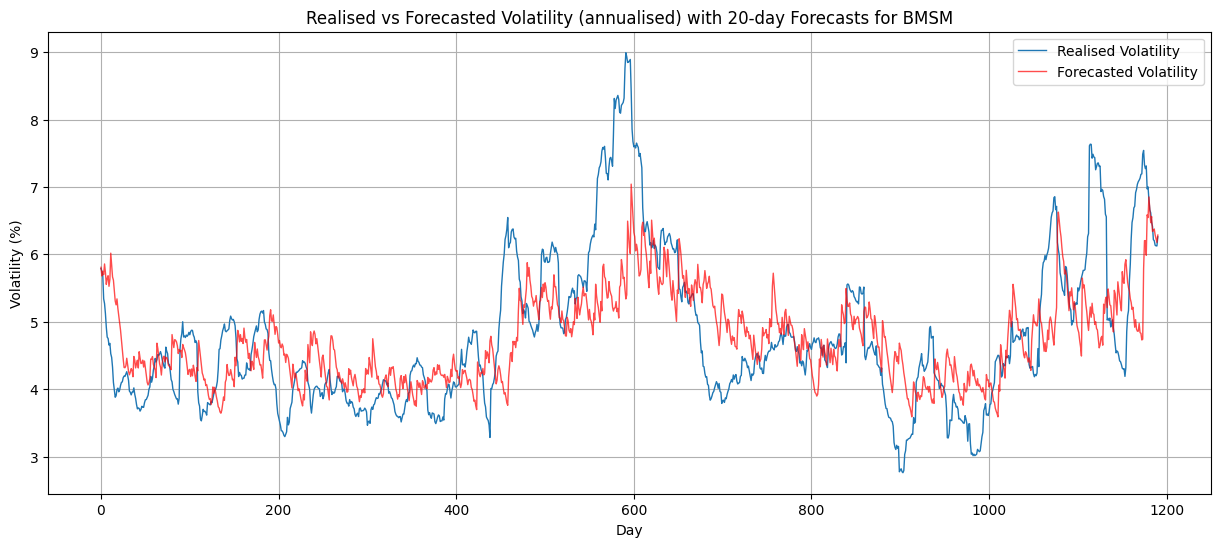

In [36]:
plt.figure(figsize=(15, 6))
plt.plot(realised_vol_H_true, color = 'tab:blue',label='Realised Volatility', linewidth=1)
plt.plot(realised_vol_H_forecasts, color = 'red', label='Forecasted Volatility', linestyle='-', linewidth=1, alpha=0.7)
plt.xlabel('Day')
plt.ylabel('Volatility (%)')
plt.title(f'Realised vs Forecasted Volatility (annualised) with {H}-day Forecasts for BMSM')
plt.grid()
plt.legend()


# Check with YEN against paper

In [341]:
# pip install pandas_datareader
import pandas_datareader.data as web
import datetime as dt

start = dt.datetime(1979, 1, 1)
end   = dt.datetime(1996, 12, 31)

df = web.DataReader('DEXJPUS', 'fred', start, end)


In [ ]:
X = df.copy()
X['r'] = np.log(X['DEXJPUS']).diff()            # this or linear r makes no diff neither does percentage on actual values
X = X[1:]
Y = X['r'].values
Y = Y[~np.isnan(Y)]  
initial_params = np.array([1.2, np.std(Y)]) 

In [ ]:
bmsm_forecasts = BMSM_Forecaster_MLE(
    initial_params=initial_params,
    train_data=Y,
    test_data = None,
    test_realised_variance=None,
    kbar=10,
    H=5, 
    scale=100, 
    b = 2.0, 
    gamma_kbar=0.5,
    percent_space=False)

result, logL = bmsm_forecasts.estimate_msm_params()

Estimated parameters: m0=1.326006e+00, sigma_bar=7.126141e-03
Final log-likelihood: 1.605247e+04


# Forecasting RV using GARCH(1, 1)

In [30]:
sgd_usd_5m = pd.read_parquet("SGD_USD_5M.parquet")  
cleaner = DataCleaner(sgd_usd_5m, start_hr=2, end_hr=18, unit_test=False) # replace US SG holidays when needed
realised_variance = cleaner.clean_data()
daily_log_returns = pd.read_parquet("SGD_USD_Daily_matched.parquet")
N = len(daily_log_returns)

train_log_returns = daily_log_returns.iloc[:int(N * 0.5)]
test_log_returns = daily_log_returns.iloc[int(N * 0.5):]
test_realised_variance = realised_variance.iloc[int(N * 0.5):]
initial_params = [1e-6, 0.15, 0.82] # omega, alpha, eta
H = 20

In [ ]:
garch_forecaster = GARCH_Forecaster(
    train_data=train_log_returns.values.flatten(),
    test_data=test_log_returns.values.flatten(),
    test_realised_variance=test_realised_variance.values.flatten(),
    initial_params=initial_params,
    p=1,
    q=1,
    H=H, 
    scale=100, 
    percent_space=True)

omega, alpha, beta, sigma2_prev = garch_forecaster.estimate_garch()

mse, R2, realised_vol_H_forecasts, realised_vol_H_true = garch_forecaster.forecast_garch()

Estimated parameters: omega=0.0005144802883575586, alpha=0.0506, beta=0.9461
Alpha + Beta = 0.9967
Final log-likelihood = 1707.9430
MSE: 0.8047013769997924, R2: 0.374797


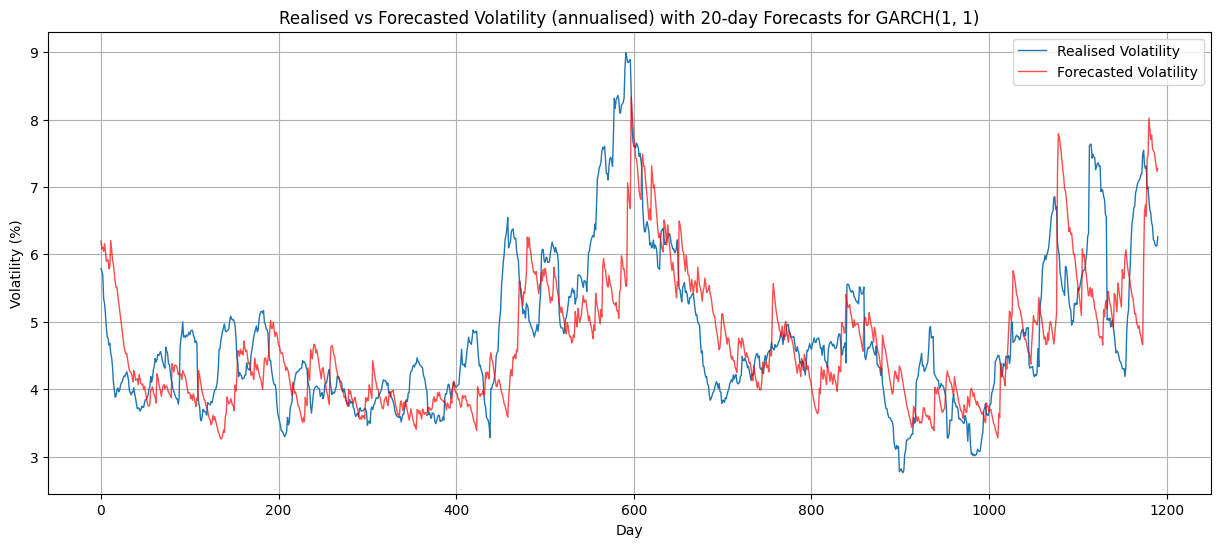

In [32]:
plt.figure(figsize=(15, 6))
plt.plot(realised_vol_H_true, color = 'tab:blue',label='Realised Volatility', linewidth=1)
plt.plot(realised_vol_H_forecasts , color = 'red', label='Forecasted Volatility', linestyle='-', linewidth=1, alpha=0.7)
plt.xlabel('Day')
plt.ylabel('Volatility (%)')
plt.title(f'Realised vs Forecasted Volatility (annualised) with {H}-day Forecasts for GARCH(1, 1)')
plt.grid()
plt.legend()


# Forecasting RV using FIGARCH(1, d, 0)

In [34]:
train_log_returns = np.load('/Users/alexvillamartin/Documents/MSc Diss/Code/all_paths_figarch.npz')['r']
train_log_returns
initial_params = [1e-4, 0.35, 0.15] # omega, d, beta

omegas = []
ds = []
betas = []

for i in range(500):
    figarch_forecaster = FIGARCH_Forecaster(
        train_data=train_log_returns[:, i],
        test_data=test_log_returns.values.flatten(),
        test_realised_variance=test_realised_variance.values.flatten(),
        initial_params=initial_params,
        p=1,
        q=0,
        H=H, 
        M=500, 
        scale=100,
        percent_space=True)

    omega, d, beta, sigma2_prev = figarch_forecaster.estimate_figarch()
    
    omegas.append(omega)
    ds.append(d)
    betas.append(beta)

Estimated parameters: omega=0.008525345190190438, d=0.4690, beta=0.2674
Final log-likelihood = 10886.2587
Estimated parameters: omega=0.007230429785356067, d=0.4398, beta=0.2507
Final log-likelihood = 11666.9345
Estimated parameters: omega=0.00719941643759551, d=0.4693, beta=0.2520
Final log-likelihood = 9463.1560
Estimated parameters: omega=0.010238465374490144, d=0.4373, beta=0.2036
Final log-likelihood = 10360.3647
Estimated parameters: omega=0.010728072819774018, d=0.4590, beta=0.2412
Final log-likelihood = 7721.4080
Estimated parameters: omega=0.008632418150362205, d=0.4597, beta=0.2472
Final log-likelihood = 10588.6836
Estimated parameters: omega=0.007328201591805674, d=0.4902, beta=0.2997
Final log-likelihood = 5271.9959
Estimated parameters: omega=0.007232416426810474, d=0.4803, beta=0.2871
Final log-likelihood = 12945.7761
Estimated parameters: omega=0.009037042393368448, d=0.4454, beta=0.2547
Final log-likelihood = 8729.4141
Estimated parameters: omega=0.007937380238343195, d

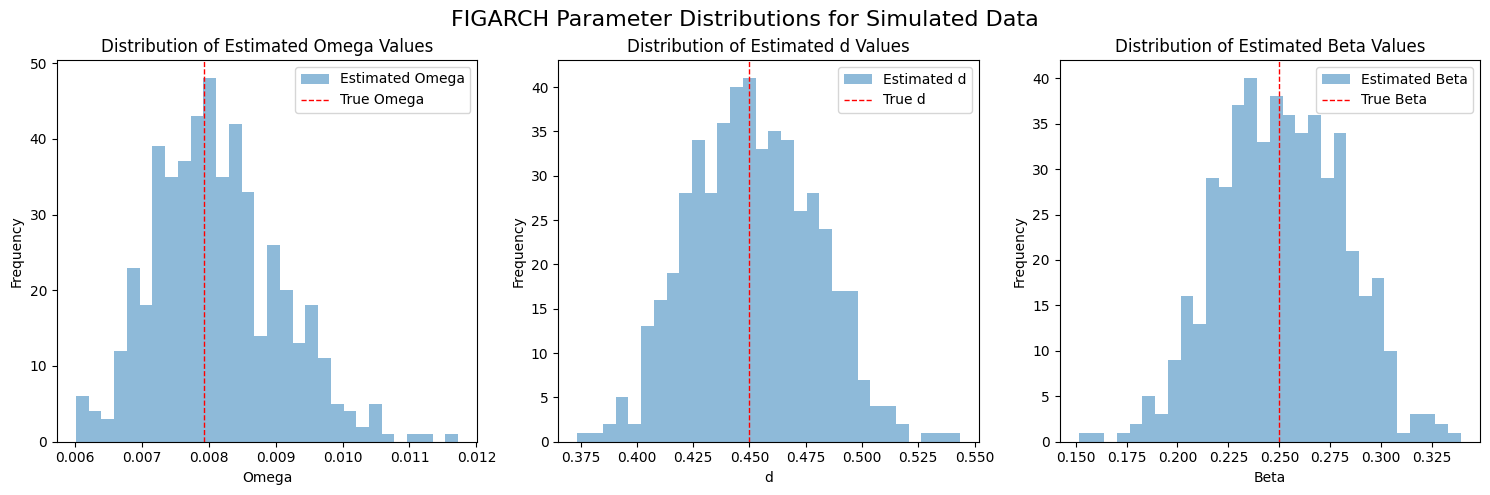

In [37]:
d_true = 0.45
b_true = 0.25
omega_true = np.array([2e-4 / 252]) * 100**2

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)

plt.hist(omegas, bins=30, alpha=0.5, label='Estimated Omega')
plt.axvline(omega_true, color='red', linestyle='dashed', linewidth=1, label='True Omega')
plt.xlabel('Omega')
plt.ylabel('Frequency')
plt.title('Distribution of Estimated Omega Values')
plt.legend()    

plt.subplot(1, 3, 2)
plt.hist(ds, bins=30, alpha=0.5, label='Estimated d')
plt.axvline(d_true, color='red', linestyle='dashed', linewidth=1, label='True d')
plt.xlabel('d')
plt.ylabel('Frequency')
plt.title('Distribution of Estimated d Values')
plt.legend()

plt.subplot(1, 3, 3)
plt.hist(betas, bins=30, alpha=0.5, label='Estimated Beta')
plt.axvline(b_true, color='red', linestyle='dashed', linewidth=1, label='True Beta')
plt.xlabel('Beta')
plt.ylabel('Frequency')
plt.title('Distribution of Estimated Beta Values')
plt.legend()

plt.tight_layout()
plt.suptitle('FIGARCH Parameter Distributions for Simulated Data', fontsize=16)
plt.subplots_adjust(top=0.88)  
plt.show()

In [42]:
# get RMSE for the estimates

rmse_omega = np.sqrt(np.mean((np.array(omegas) - omega_true)**2))
rmse_d = np.sqrt(np.mean((np.array(ds) - d_true)**2))
rmse_beta = np.sqrt(np.mean((np.array(betas) - b_true)**2))

print(f"RMSE Omega: {rmse_omega:.6f}, RMSE d: {rmse_d:.6f}, RMSE Beta: {rmse_beta:.6f}")


RMSE Omega: 0.000946, RMSE d: 0.027766, RMSE Beta: 0.030451


## Empirical

In [55]:
sgd_usd_5m = pd.read_parquet("SGD_USD_5M.parquet")  
cleaner = DataCleaner(sgd_usd_5m, start_hr=2, end_hr=18, unit_test=False) # replace US SG holidays when needed
realised_variance = cleaner.clean_data()
daily_log_returns = pd.read_parquet("SGD_USD_Daily_matched.parquet")
N = len(daily_log_returns)

train_log_returns = daily_log_returns.iloc[:int(N * 0.5)]
test_log_returns = daily_log_returns.iloc[int(N * 0.5):]
test_realised_variance = realised_variance.iloc[int(N * 0.5):]
initial_params = [1e-4, 0.35, 0.25] # omega, d, beta
H = 20
M = 1000

In [56]:
figarch_forecaster = FIGARCH_Forecaster(
    train_data=train_log_returns.values.flatten(),
    test_data=test_log_returns.values.flatten(),
    test_realised_variance=test_realised_variance.values.flatten(),
    initial_params=initial_params,
    p=1,
    q=0,
    H=H, 
    M=M, 
    scale=100,
    percent_space=True)

omega, d, beta, sigma2_prev = figarch_forecaster.estimate_figarch()

mse, R2, realised_vol_H_forecasts, realised_vol_H_true = figarch_forecaster.forecast_figarch()

Estimated parameters: omega=0.009298443394519748, d=0.4538, beta=0.3909
Final log-likelihood = 1666.9120
MSE: 0.9633802420215465, R2: 0.251514


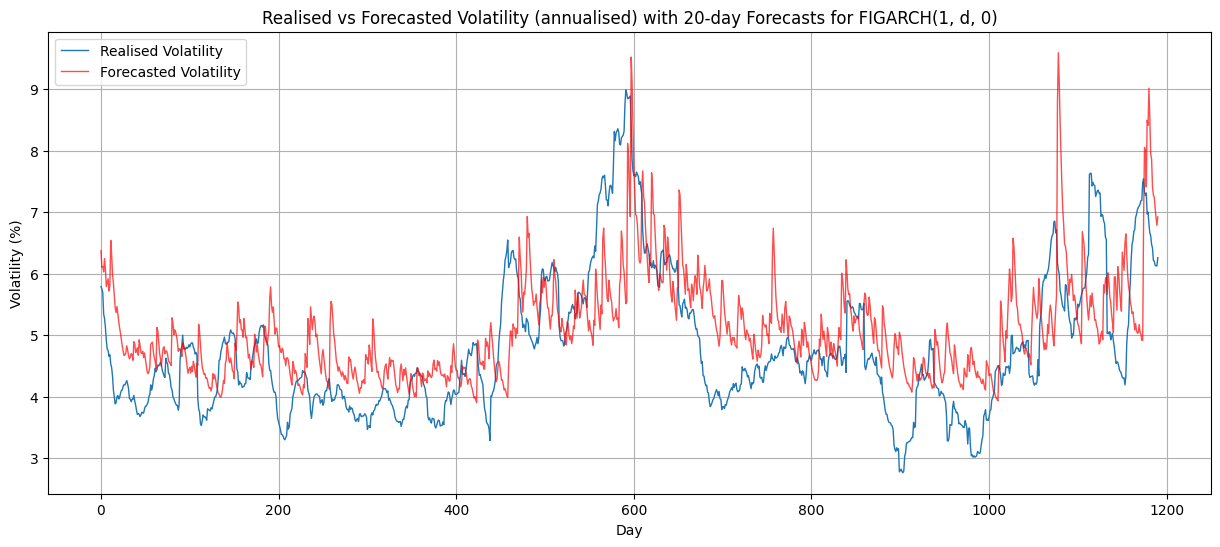

In [57]:
plt.figure(figsize=(15, 6))
plt.plot(realised_vol_H_true , color = 'tab:blue',label='Realised Volatility', linewidth=1)
plt.plot(realised_vol_H_forecasts , color = 'red', label='Forecasted Volatility', linestyle='-', linewidth=1, alpha=0.7)
plt.xlabel('Day')
plt.ylabel('Volatility (%)')
plt.title(f'Realised vs Forecasted Volatility (annualised) with {H}-day Forecasts for FIGARCH(1, d, 0)')
plt.grid()
plt.legend()
